In [1]:
import numpy as np
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns
import platform

In [2]:
# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

In [3]:
filepath = './source/소상공인시장진흥공단_상가(상권)정보_서울_202512.csv'
df = pd.read_csv(filepath, sep=',' , encoding='utf-8')
df.head()

,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
0,MA010120220804265295,60계치킨암사,선사점,I2,음식,I210,기타 간이,I21006,치킨,I56193,...,1174010700105020004015779,암사동정웅빌딩,서울특별시 강동구 상암로3길 8,134877,5241,NaN,1,NaN,127.126859,37.550810
1,MA010120220809658173,성심인력공사,NaN,N1,시설관리·임대,N104,고용 알선,N10401,고용 알선업,N75110,...,1117010700100430059022991,NaN,서울특별시 용산구 한강대로 385,140821,4320,NaN,NaN,NaN,126.972240,37.552803
2,MA010120220808205276,칸토빈,NaN,I2,음식,I212,비알코올,I21201,카페,I56221,...,1150010800200200002002536,공항시장역,서울특별시 강서구 방화동로 30,157240,7619,NaN,1,NaN,126.810493,37.563548
3,MA010120220804370987,까치노래연습장,NaN,R1,예술·스포츠,R104,유원지·오락,R10407,노래방,R91223,...,1135010500101690179002482,NaN,서울특별시 노원구 한글비석로23길 2,139815,1682,NaN,NaN,NaN,127.071218,37.660715
4,MA010120220810170381,금빛주얼리,NaN,G2,소매,G217,시계·귀금속 소매,G21701,시계/귀금속 소매업,G47830,...,1111015100100880001000001,종로주얼리타운,서울특별시 종로구 돈화문로10길 2,110370,3138,NaN,1,NaN,126.991861,37.572331


In [4]:
df.shape

(534978, 39)

In [5]:
df.columns

Index(['상가업소번호', '상호명', '지점명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드',
       '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드',
       '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드',
       '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드', '도로명', '건물본번지',
       '건물부번지', '건물관리번호', '건물명', '도로명주소', '구우편번호', '신우편번호', '동정보', '층정보',
       '호정보', '경도', '위도'],
      dtype='str')

In [6]:
set(df['상권업종대분류명'])

{'과학·기술', '교육', '보건의료', '부동산', '소매', '수리·개인', '숙박', '시설관리·임대', '예술·스포츠', '음식'}

In [7]:
print(set(df['상권업종중분류명']))

{'가전·통신 소매', '동남아시아', '병원', '고용 알선', '기술 서비스', '청소·방제', '주점', '사진 촬영', '섬유·의복·신발 소매', '자동차 수리·세차', '의원', '비알코올 ', '이용·미용', '산업용품 대여', '세탁', '인쇄·제품제작', '욕탕·신체관리', '시장 조사', '법무관련 ', '일반 숙박', '컴퓨터 수리', '본사·경영 컨설팅', '일식', '식물 소매', '시계·귀금속 소매', '사무 지원', '부동산 서비스', '장식품 소매', '모터사이클 소매', '기타 사업 서비스', '기타 숙박', '연료 소매', '담배 소매', '전문 디자인', '중고 상품 소매', '서양식', '자동차 부품 소매', '조경·유지', '철물·건설자재 소매', '일반 교육', '유원지·오락', '스포츠 서비스', '기타 생활용품 소매', '도서관·사적지', '애완동물·용품 소매', '가구 소매', '기타 상품 소매', '한식', '가전제품 수리', '기타 보건', '교육 지원', '종합 소매', '기타 교육', '수의', '장례식장 ', '기타 가정용품 수리', '구내식당·뷔페', '기타 외국', '중식', '가정용품 대여', '안경·정밀기기 소매', '기타 개인', '회계·세무', '시설관리', '기타 전문 과학', '모터사이클 수리', '오락용품 소매', '기타 간이', '광고', '식료품 소매', '운송장비 대여', '통신장비 수리', '의약·화장품 소매', '음료 소매', '여행사·보조'}


In [9]:
# 결측치
df.isnull().sum()

상가업소번호            0
상호명               0
지점명          487042
상권업종대분류코드         0
상권업종대분류명          0
상권업종중분류코드         0
상권업종중분류명          0
상권업종소분류코드         0
상권업종소분류명          0
표준산업분류코드        199
표준산업분류명         199
시도코드              0
시도명               0
시군구코드             0
시군구명              0
행정동코드             0
행정동명              0
법정동코드             0
법정동명              0
지번코드              0
대지구분코드            0
대지구분명             0
지번본번지            25
지번부번지         94362
지번주소              0
도로명코드             0
도로명               0
건물본번지             2
건물부번지        465474
건물관리번호         2342
건물명          278767
도로명주소             0
구우편번호             0
신우편번호             0
동정보          534978
층정보          187990
호정보          534978
경도                0
위도                0
dtype: int64

In [10]:
df['시도명'].unique()

<StringArray>
['서울특별시']
Length: 1, dtype: str

In [11]:
# 결측시를 시각화해서 볼 수 있다.
import missingno as msno

<Axes: >

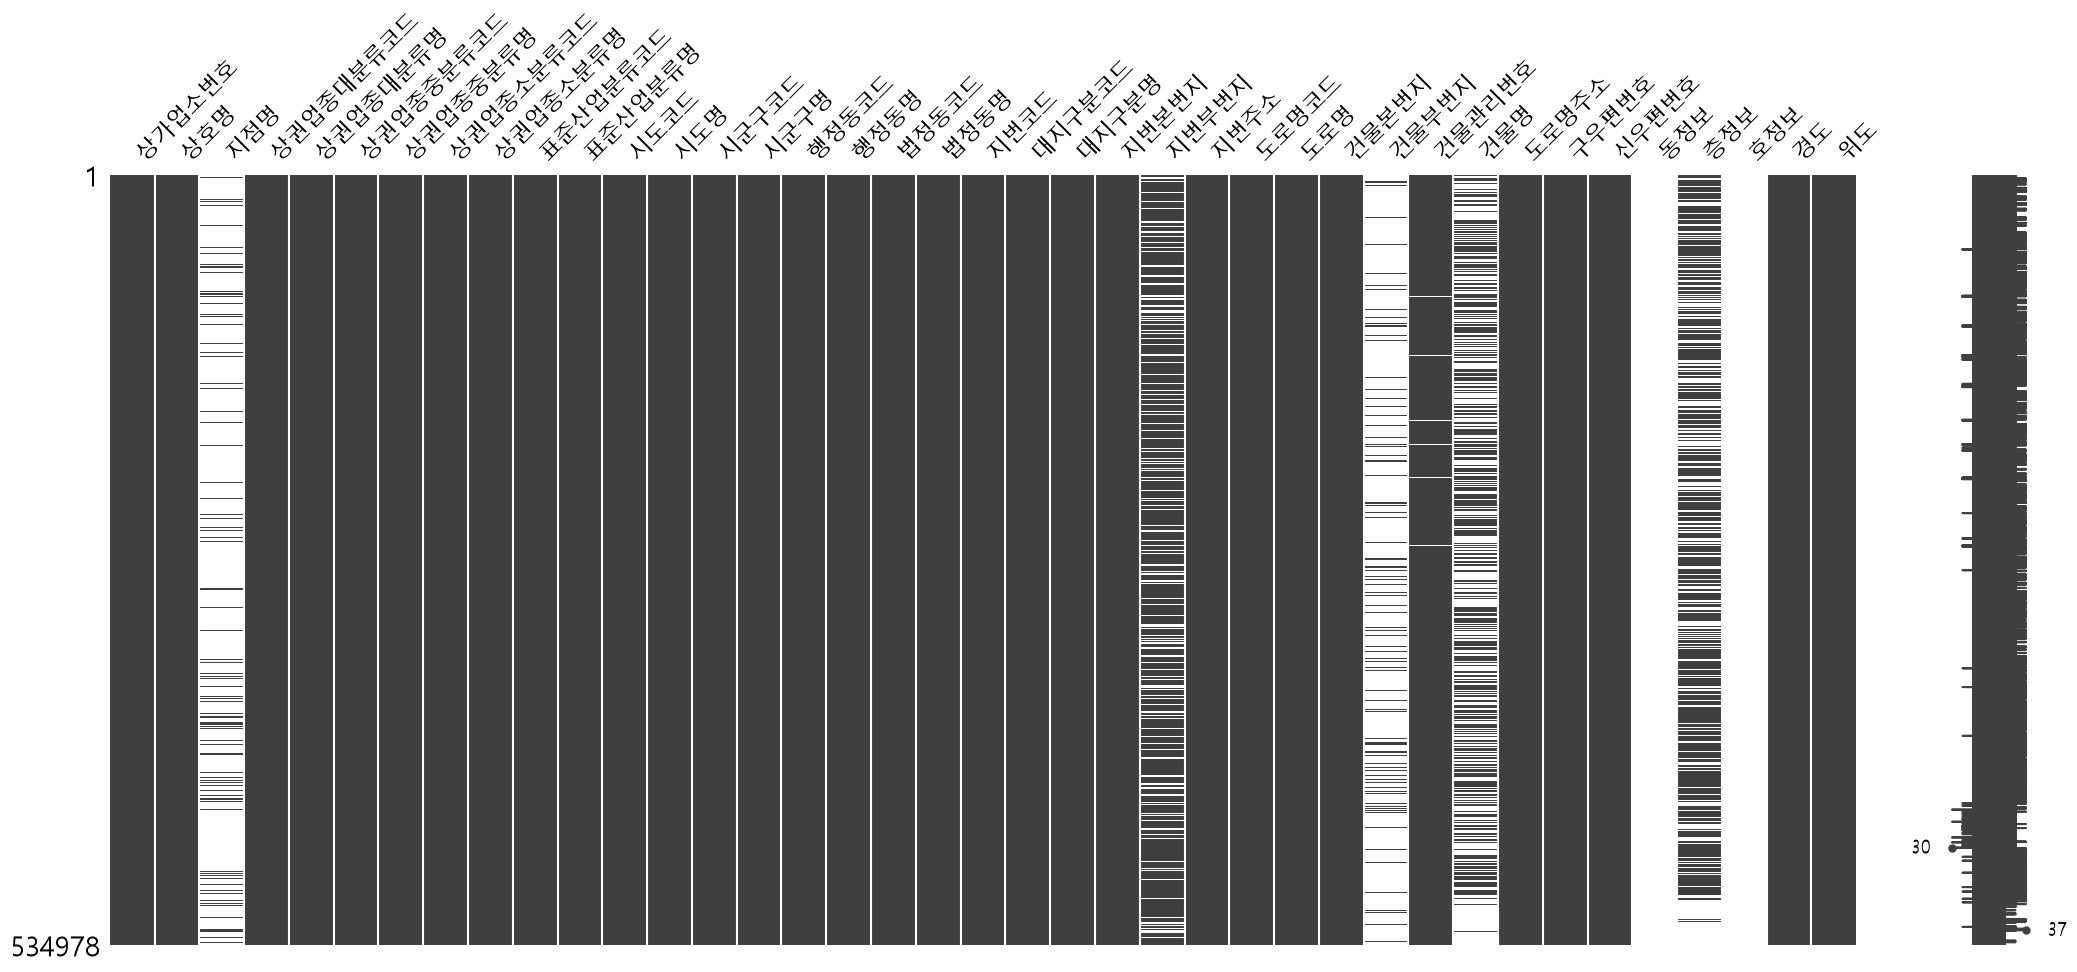

In [12]:
msno.matrix(df)

In [13]:
df['상권업종대분류명'].value_counts()

상권업종대분류명
음식         135884
소매         111632
과학·기술       93261
수리·개인       51626
교육          45158
부동산         25059
시설관리·임대     24231
예술·스포츠      20446
보건의료        18840
숙박           8841
Name: count, dtype: int64

In [14]:
# df['상권업종대분류명']=='음식'    VS  df['상권업종대분류명'].str.contains('음식')  서로 같다
#df[df['상권업종대분류명']=='음식']

df_food = df.loc[df['상권업종대분류명'].str.contains('음식')]
df_food.shape

(135884, 39)

In [15]:
df_food.head()

,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
0,MA010120220804265295,60계치킨암사,선사점,I2,음식,I210,기타 간이,I21006,치킨,I56193,...,1174010700105020004015779,암사동정웅빌딩,서울특별시 강동구 상암로3길 8,134877,5241,NaN,1,NaN,127.126859,37.550810
2,MA010120220808205276,칸토빈,NaN,I2,음식,I212,비알코올,I21201,카페,I56221,...,1150010800200200002002536,공항시장역,서울특별시 강서구 방화동로 30,157240,7619,NaN,1,NaN,126.810493,37.563548
8,MA010120220809640417,솜노래팡팡,NaN,I2,음식,I211,주점,I21104,요리 주점,I56219,...,1165010800115770002022148,NaN,서울특별시 서초구 서초대로50길 75,137875,6650,NaN,1,NaN,127.013852,37.489862
15,MA010120220812811919,읏듬돈생삼겹살,NaN,I2,음식,I201,한식,I20107,돼지고기 구이/찜,I56113,...,1129013900103840023002884,NaN,서울특별시 성북구 화랑로40길 43,136817,2781,NaN,1,NaN,127.064015,37.613579
36,MA010120220809620318,동원기사식당,NaN,I2,음식,I201,한식,I20101,백반/한정식,I56111,...,1147010100102100006000001,NaN,서울특별시 양천구 목동남로 64-1,158851,8101,NaN,1,NaN,126.866492,37.509645


### 이디야와 할리스

In [16]:
df.columns

Index(['상가업소번호', '상호명', '지점명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드',
       '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드',
       '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드',
       '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드', '도로명', '건물본번지',
       '건물부번지', '건물관리번호', '건물명', '도로명주소', '구우편번호', '신우편번호', '동정보', '층정보',
       '호정보', '경도', '위도'],
      dtype='str')

In [17]:
dataset = df[['상호명', '지점명', '상권업종중분류명', '시도명', '시군구명', '행정동명', '도로명', '경도', '위도']]
dataset.head()

#print(dataset['상권업종중분류명'].unique())

# '비알코올' 뒤에 공백이 있으므로 주의하세요
df_coffee = dataset[dataset['상권업종중분류명']=='비알코올 ']
df_coffee.head()

,상호명,지점명,상권업종중분류명,시도명,시군구명,행정동명,도로명,경도,위도
2,칸토빈,NaN,비알코올,서울특별시,강서구,공항동,서울특별시 강서구 방화동로,126.810493,37.563548
56,빽다방구산역점,NaN,비알코올,서울특별시,은평구,구산동,서울특별시 은평구 연서로,126.916688,37.610477
75,맹커피숍,NaN,비알코올,서울특별시,은평구,대조동,서울특별시 은평구 불광로,126.928818,37.610773
108,담다,NaN,비알코올,서울특별시,동대문구,용두동,서울특별시 동대문구 왕산로19가길,127.031631,37.581067
124,초원,NaN,비알코올,서울특별시,동대문구,신설동,서울특별시 동대문구 왕산로,127.024498,37.576284


In [18]:
df_coffee['상권업종중분류명'].unique()

<StringArray>
['비알코올 ']
Length: 1, dtype: str

In [19]:
print(df_coffee['상호명'])

2                   칸토빈
56              빽다방구산역점
75                 맹커피숍
108                  담다
124                  초원
              ...      
534883    메가엠지씨커피서울서일초점
534915            바나프레소
534926              다이스
534959       이디야커피르피에드점
534976             만월다방
Name: 상호명, Length: 21624, dtype: str


In [20]:
print(sorted(list(set(df_coffee['상호명']))))

['(주)이테크건설산업 묵정동지점', '000케이크바', '0122 커피바(0122 coffee bar)', '0125커피바', '01팩토리', '025베이커리', '09커피', '1%리버티커피', '1.5도씨', '100X커피', '101빌리지', '101스트릿노블레르점', '101커피', '101커피컨테이너', '101파트너스', '1059-3베이글커피하우스', '106길15', '10꼬르소꼬모', '10꼬르소꼬모카페', '10스퀘어남산', '10스퀘어오슬로회현', '11월', '120겹파이', '121호', '125수유', '132하우스', '139커피', '13포레스트', '1441카페로스터스', '14번가', '153카페', '15아지트', '175도씨', '17도씨', '17번지넘버링', '1847카페', '193씨엠', '1980벽돌집', '1999커피', '1LL일', '1달러커피', '1인1잔', '1한가로이', '2.카페', '207', '208도씨', '208호', '210커피', '213점', '214베이커스트리트', '22그램', '237플랫폼카페', '24/7', '24CAFE33커피상왕십리역', '24시만화카페', '24시무인까페만월경병무청역점', '24시무인까페만월경서리풀점', '24시무인셀프카페', '24시무인셀프카페원효로점', '24시무인카페', '24시무인카페RO', '24시무인카페만월경', '24시무인카페만월경&음악연습실', '24시무인카페만월경노원마들역점', '24시무인카페만월경면', '24시무인카페만월경북', '24시무인카페만월경상계', '24시무인카페만월경수락산역점', '24시무인카페만월경잠실레이크', '24시무인카페만월경점', '24시무인카페만월경화랑대점', '25그램', '25브릭스', '26;샵', '26카페', '282독', '29커피', '2라운드', '2층라이브러리', '2층사무실', '2층집', '2카페', '301에이치', '312스튜디오', '33마켓', '33아파트먼트', '33카페', '36.5도씨여

In [21]:
df_coffee[df_coffee['상호명'].str.contains('이디야|ediya|EDIYA')].shape

(433, 9)

In [22]:
df_coffee[df_coffee['상호명'].str.contains('할리스|hollys|HOLLYS')].shape

(111, 9)

In [23]:
df_coffee.loc[df_coffee['상호명'].str.contains('이디야|ediya|EDIYA'),'상호명'].unique()

<StringArray>
[        '이디야커피',        '이디야성산점',           '이디야',        '이디야강서점',
        '이디야커피숍',        '이디야포이점',    '이디야연신내통일로점',          '이디야주',
         '이디야삼성',     '이디야커피길동역점',
 ...
         '이디야역삼',       '이디야상계동점',        '이디야커피랩', '성신씨엔엠이디야성수2가점',
          '이디야삼',       '이디야대방역점',    '이디야커피대림1동점', '이디야커피서울숲리버포레점',
    '이디야커피광흥창역점',    '이디야커피르피에드점']
Length: 314, dtype: str

In [24]:
# 이디야와 할리스 데이터 가져오기
df_coffee_edi_holly =  df_coffee.loc[df_coffee['상호명'].str.contains('이디야|ediya|EDIYA|할리스|hollys|HOLLYS')].copy()
df_coffee_edi_holly.shape

(544, 9)

In [25]:
df_coffee_edi_holly.sample(5)

,상호명,지점명,상권업종중분류명,시도명,시군구명,행정동명,도로명,경도,위도
358532,이디야커피,NaN,비알코올,서울특별시,강남구,도곡2동,서울특별시 강남구 논현로,127.043032,37.482412
247503,할리스도심2,공항점,비알코올,서울특별시,강남구,삼성1동,서울특별시 강남구 테헤란로87길,127.059448,37.509634
517692,할리스커피신촌연세로점,NaN,비알코올,서울특별시,서대문구,신촌동,서울특별시 서대문구 연세로,126.936577,37.556132
521276,할리스커피대명,거리점,비알코올,서울특별시,종로구,혜화동,서울특별시 종로구 대명길,127.001076,37.583756
82100,할리스커피홍대역2번,출구점,비알코올,서울특별시,마포구,서교동,서울특별시 마포구 동교로,126.923119,37.557755


In [26]:
# 상호명에 이디야가 포함된 것에 브랜드명 컬럼명을 추가하고 '이디야'을 저장한다.
df_coffee_edi_holly.loc[df_coffee_edi_holly['상호명'].str.contains('이디야|ediya|EDIYA'),'브랜드명'] ='이디야'

In [27]:
df_coffee_edi_holly.sample(5)

,상호명,지점명,상권업종중분류명,시도명,시군구명,행정동명,도로명,경도,위도,브랜드명
176526,이디야커피건대스타시티점,NaN,비알코올,서울특별시,광진구,자양3동,서울특별시 광진구 아차산로,127.072956,37.537008,이디야
472601,이디야건대역점,NaN,비알코올,서울특별시,광진구,화양동,서울특별시 광진구 아차산로,127.068988,37.540812,이디야
48124,이디야혜화역점,NaN,비알코올,서울특별시,종로구,혜화동,서울특별시 종로구 창경궁로,127.000645,37.583594,이디야
321713,할리스개화산점,NaN,비알코올,서울특별시,강서구,방화2동,서울특별시 강서구 양천로,126.806973,37.572282,NaN
429994,이디야커피,쌍문역점,비알코올,서울특별시,도봉구,쌍문3동,서울특별시 도봉구 도봉로117길,127.034709,37.649442,이디야


In [28]:
df_coffee_edi_holly['브랜드명'].unique()

<StringArray>
['이디야', nan]
Length: 2, dtype: str

In [29]:
df_coffee_edi_holly['브랜드명'].value_counts()

브랜드명
이디야    433
Name: count, dtype: int64

In [30]:
geo_df_coffee =  df_coffee_edi_holly.copy()

In [ ]:
#!pip install folium

In [31]:
import folium

In [32]:
folium.Map

folium.folium.Map

In [33]:
map = folium.Map(location=[geo_df_coffee['위도'].mean(), geo_df_coffee['경도'].mean()],
           zoom_start=12, tiles='OpenStreetMap')  # tiles='OpenStreetMap'


for n in geo_df_coffee.index:
  #팝업에 들어갈 텍스트를 지정해 준다.
  popup_name=geo_df_coffee.loc[n,'상호명'] + ' - '\
  +geo_df_coffee.loc[n, '도로명']

  if geo_df_coffee.loc[n,'브랜드명']=='이디야':
    icon_color='blue'
  else:
    icon_color='red'

  folium.CircleMarker(
      location=[geo_df_coffee.loc[n, '위도'],geo_df_coffee.loc[n,'경도']],
      radius = 3,
      popup =popup_name,
      color = icon_color,
      fill=True,
      fill_color=icon_color
  ).add_to(map)


In [34]:
map